<h2 style="color:Purple; font-family:; text-align:center;font-size:35px">
  ❁۪ ｡˚ SVMs y optimización de hiperparámetros ❁۪ ｡˚
</h2>
<h1 style="color:Purple; font-size:13.5px;"> Student: </h1>Ornella Cañellas Arredondo 
<h1 style="color:Purple; font-size:13.5px;"> Rol:  </h1>202387002-1
<h1 style="color:Purple; font-size:13.5px;"> Professor and Assistant: </h1> Pía Amigo and Joseph Dabre


En este notebook trabajaremos con un dataset simulado de eventos del experimento ATLAS. Cada fila representa un evento de colisión protón–protón, y cada columna corresponde a una variable reconstruida a partir de los objetos físicos detectados en el evento: jets, leptones, energía faltante, etc.

El objetivo es distinguir entre dos tipos de eventos:

- **`ttbar`**: producción de un par top–antitop. Es un proceso mucho más frecuente.
- **`4top`**: producción de cuatro quarks top. Es un proceso mucho más raro y corresponde a nuestra clase positiva.


Basado en Machine learning for physics and Astronomy, Viviana Acquaviva (2023)





In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc
from sklearn.svm import SVC, LinearSVC # Nuevo algoritmo!
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, cross_validate
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn import metrics
from sklearn.model_selection import GridSearchCV # Nuevo! Para explorar los hiperparámetros del modelo

In [2]:
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_colwidth', 100)
rc('text', usetex=False)

Leemos las características y las etiquetas  

In [3]:
features = pd.read_csv('ParticleID_features.csv', index_col='ID')

In [4]:
features.head(10)

,MET,METphi,Type_1,P1,P2,P3,P4,Type_2,P5,P6,P7,P8,Type_3,P9,P10,P11,P12,Type_4,P13,P14,P15,P16,Type_5,P17,P18,P19,P20,Type_6,P21,P22,P23,P24,Type_7,P25,P26,P27,P28,Type_8,P29,P30,P31,P32,Type_9,P33,P34,P35,P36,Type_10,P37,P38,P39,P40,Type_11,P41,P42,P43,P44,Type_12,P45,P46,P47,P48,Type_13,P49,P50,P51,P52
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,62803.50,-1.810010,j,137571.0,128444.0,-0.345744,-0.307112,j,174209.0,127932.0,0.826569,2.332000,b,86788.9,84554.9,-0.180795,2.187970,j,140289.0,76955.8,-1.199330,-1.302800,m+,85230.6,70102.4,-0.645689,-1.659540,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,57594.20,-0.509253,j,161529.0,80458.3,-1.318010,1.402050,j,291490.0,68462.9,-2.126740,-2.582310,e-,44270.1,35139.6,-0.706120,-0.371392,e+,72883.9,26902.2,-1.653860,-3.129630,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,82313.30,1.686840,b,167130.0,113078.0,0.937258,-2.068680,j,102423.0,54922.3,1.226850,0.646589,j,60768.9,36244.3,1.102890,-1.434480,j,77714.0,27801.5,1.684610,1.389690,j,26840.0,24469.3,-0.388937,-1.647260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,30610.80,2.617120,j,112267.0,61383.9,-1.211050,-1.457800,b,40647.8,39472.0,-0.024646,-2.222800,j,201589.0,32978.6,-2.496040,1.137810,j,90096.7,26964.5,1.871320,0.817631,j,28235.4,25887.9,-0.411528,2.024290,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,45153.10,-2.241350,j,178174.0,100164.0,1.166880,-0.018721,j,92351.3,69762.1,0.774114,2.568740,j,61625.2,50086.7,0.652572,-3.012800,j,104193.0,31151.0,1.876410,0.865381,j,746585.0,26219.3,4.041820,-0.874169,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,43803.10,0.572184,b,146274.0,111016.0,-0.776311,1.083980,j,1036150.0,109475.0,-2.937790,-1.518380,j,259026.0,71613.8,-1.955480,-1.726540,j,137198.0,59925.9,-1.469500,2.189410,j,95419.6,55847.5,1.123310,0.846395,j,451389.0,53178.9,-2.827840,-2.47964,j,51436.4,50713.2,0.056029,2.258540,j,152293.0,48842.5,-1.80056,-0.704609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,28100.40,-0.593429,j,458244.0,391557.0,-0.546723,0.013275,b,425427.0,328566.0,-0.728581,-2.411570,j,126694.0,116820.0,-0.350992,2.208790,j,112382.0,111318.0,0.073453,3.030960,j,3039490.0,65143.9,4.535880,1.516880,j,86235.2,65037.1,0.780704,1.50869,b,62675.6,61535.7,0.099510,0.466516,j,82070.6,45537.5,-1.18149,-3.047850,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,166458.00,0.473635,j,848058.0,273398.0,-1.794510,2.763560,j,267149.0,242308.0,-0.425923,-1.534860,b,461064.0,159944.0,-1.719880,1.094360,j,75909.0,73858.8,-0.235076,-0.330519,b,201351.0,53338.2,-2.002180,-2.376840,b,38794.0,37225.5,0.187429,-2.78635,b,40323.4,36915.1,0.411490,1.844490,j,195049.0,28645.2,-2.60528,-1.434260,j,210687.0,26560.5,2.75992,0.315873,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,4664.13,-1.828120,j,477219.0,331550.0,-0.899484,0.698675,b,696365.0,246682.0,-1.697140,-2.285070,j,987005.0,62516.5,-3.451230,-2.207720,j,51561.9,36406.3,-0.881624,-2.923760,j,85262.1,35203.6,-1.527390,2.071480,j,202166.0,26361.8,-2.725680,-2.21350,j,56071.6,25934.6,-1.403180,1.130990,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Cada fila del dataset corresponde a un evento de colisión protón-protón.
Para cada evento se conoce:
- Energía faltante:
  - `MET`: energía transversa faltante (*missing transverse energy*)
  - `METphi`: ángulo azimutal asociado a la dirección de la energía faltante
- Información de cada partícula reconstruida: Para cada partícula se registra:
    - Tipo de partícula, que puede ser: electrón, positrón, fotón, jet, b-jet, muón con carga positiva, muón con carga negativa
    - 4-vector, que describe la cinemática de la partícula. En este dataset, el 4-vector incluye: energía, momento transversal, pseudorapidez $\eta$ y ángulo azimutal $\phi$


In [5]:
features.shape
y = np.genfromtxt('ParticleID_labels.txt', dtype = str)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder() 
y = le.fit_transform(y)
le.classes_
target = np.abs(y - 1)

In [6]:
y = np.genfromtxt('ParticleID_labels.txt', dtype = str)

In [7]:
y

array(['ttbar', 'ttbar', 'ttbar', ..., 'ttbar', '4top', 'ttbar'],
      dtype='<U5')

### Objetivo del problema

Queremos entrenar un clasificador que distinga entre dos tipos de eventos:

- `ttbar`: producción de un par top-antitop.
- `4top`: producción de cuatro quarks top.

#### Necesitamos transformar las dos categorías de targets desde un string a un valor numérico, como 0/1. Podemos usar la función [`LabelEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) de sklearn

In [8]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder() #cambia las categorías a 1...N

In [9]:
y

array(['ttbar', 'ttbar', 'ttbar', ..., 'ttbar', '4top', 'ttbar'],
      dtype='<U5')

In [10]:
y = le.fit_transform(y)

In [11]:
le.classes_

array(['4top', 'ttbar'], dtype='<U5')

`LabelEncoder` asigna números a las clases en el orden definido por `le.classes_`.  
Como queremos que `4top` sea la clase positiva, revisamos la codificación y, si es necesario, invertimos las etiquetas.

In [12]:
target = np.abs(y - 1)

In [13]:
target # Ahora sí

array([0, 0, 0, ..., 0, 1, 0])

In [14]:
y.shape

(5000,)

#### Echemos un vistazo a las características

In [15]:
features.describe() #Esto excluye a las columnas con datos no-numéricos

,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16,P17,P18,P19,P20,P21,P22,P23,P24,P25,P26,P27,P28,P29,P30,P31,P32,P33,P34,P35,P36,P37,P38,P39,P40,P41,P42,P43,P44,P45,P46,P47,P48,P49,P50,P51,P52
count,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,4.997000e+03,4.997000e+03,4997.000000,4997.000000,4.950000e+03,4950.000000,4950.000000,4950.000000,4.717000e+03,4717.000000,4717.000000,4717.000000,4.002000e+03,4002.000000,4002.000000,4002.000000,2.871000e+03,2871.00000,2871.000000,2871.000000,1.889000e+03,1889.000000,1889.000000,1889.000000,1.186000e+03,1186.000000,1186.000000,1186.000000,7.290000e+02,729.000000,729.000000,729.000000,4.420000e+02,442.000000,442.000000,442.000000,2.610000e+02,261.000000,261.000000,261.000000,1.270000e+02,127.000000,127.000000,127.000000,5.600000e+01,56.000000,56.000000,56.000000
mean,64071.074332,-0.028916,3.301357e+05,1.540486e+05,-0.039812,-0.003049,2.527799e+05,1.080302e+05,-0.029936,0.007327,2.117980e+05,74863.343131,-0.025104,0.011845,1.805997e+05,57289.049481,0.010723,0.045266,1.780366e+05,48798.018516,0.015167,-0.031312,1.705620e+05,44042.67015,-0.022948,0.014522,1.628825e+05,41151.069666,0.002228,0.006738,1.581409e+05,40250.387015,0.072349,-0.035907,1.596814e+05,40139.289849,0.061654,-0.045868,1.574039e+05,39703.038235,0.118543,0.024249,1.561160e+05,38173.716092,0.029455,0.026422,1.631051e+05,34876.849606,0.206978,-0.001085,1.456600e+05,36151.183929,-0.000879,0.219260
std,60525.122480,1.819257,3.068202e+05,1.149469e+05,1.361762,1.814855,2.638580e+05,8.136261e+04,1.439105,1.828832,2.510361e+05,46309.512365,1.577316,1.802715,2.383403e+05,32013.857623,1.634072,1.812078,2.577958e+05,26252.978520,1.744489,1.784248,2.381745e+05,23510.65367,1.806611,1.811101,2.269341e+05,20988.953157,1.815312,1.771888,2.118782e+05,26556.025657,1.836492,1.796932,2.308620e+05,30074.756789,1.842798,1.788596,2.165489e+05,30502.312276,1.872084,1.826435,2.319016e+05,29324.658352,1.884750,1.753017,2.248603e+05,20433.767238,1.998859,1.949004,1.943657e+05,25861.883410,1.941707,1.910400
min,290.756000,-3.141010,3.857940e+04,2.825400e+04,-4.110220,-3.140710,1.087540e+04,1.080000e+04,-4.668790,-3.140530,1.221050e+04,10639.800000,-4.520250,-3.141480,1.169190e+04,10818.000000,-4.616550,-3.136130,1.110310e+04,10287.000000,-4.778980,-3.139040,1.070330e+04,10066.90000,-4.930230,-3.140380,1.197700e+04,11260.200000,-4.758150,-3.135630,1.380860e+04,10973.300000,-4.606330,-3.132610,1.119760e+04,10067.900000,-4.814380,-3.136380,1.615530e+04,10183.700000,-4.803880,-3.135910,2.004750e+04,14800.200000,-4.400470,-3.130690,1.780380e+04,12987.900000,-4.447660,-3.139820,2.512510e+04,14836.000000,-4.448760,-2.990730
25%,24352.375000,-1.619905,1.369522e+05,8.883690e+04,-1.035570,-1.574213,1.007510e+05,6.321840e+04,-1.060500,-1.602460,7.636905e+04,46549.475000,-1.125620,-1.547418,5.999090e+04,36097.700000,-1.121240,-1.518030,5.278370e+04,30891.650000,-1.198468,-1.550615,5.007050e+04,28453.95000,-1.250050,-1.586675,4.695560e+04,27963.500000,-1.231420,-1.475380,4.535515e+04,27140.550000,-1.243962,-1.626688,4.387110e+04,26825.000000,-1.226980,-1.513330,4.410735e+04,26589.250000,-1.223240,-1.422415,4.092160e+04,25298.300000,-1.413650,-1.270700,4.365005e+04,24742.500000,-1.259230,-1.817600,4.112588e+04,24974.125000,-1.243362,-1.490900
50%,46814.400000,-0.055612,2.263525e+05,1.182015e+05,-0.038731,-0.009037,1.659740e+05,8.584360e+04,-0.057428,0.015111,1.288565e+05,62498.400000,-0.040648,0.034238,9.922610e+04,48949.200000,-0.035512,0.060279,9.206885e+04,41054.850000,0.054393,-0.079641,8.593460e+04,37378.30000,-0.046667,0.040528,7.975460e+04,34681.700000,0.025305,0.046141,8.315485e+04,33683.550000,0.156083,-0.015617,7.894980e+04,33328.000000,0.072709,-0.052590,7.609735e+04,30942.700000,0.035675,0.090282,7.568430e+04,29479.700000,-0.088908,-0.041002,8.050910e+04,28262.800000,0.120301,-0.232455,9.553645e+04,27353.550000,-0.121213,0.128103
75%,83032.350000,1.537323,4.077158e+05,1.771265e+05,0.943598,1.542370,2.9999

In [16]:
features.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 67 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   MET      5000 non-null   float64
 1   METphi   5000 non-null   float64
 2   Type_1   5000 non-null   str    
 3   P1       5000 non-null   float64
 4   P2       5000 non-null   float64
 5   P3       5000 non-null   float64
 6   P4       5000 non-null   float64
 7   Type_2   4997 non-null   str    
 8   P5       4997 non-null   float64
 9   P6       4997 non-null   float64
 10  P7       4997 non-null   float64
 11  P8       4997 non-null   float64
 12  Type_3   4950 non-null   str    
 13  P9       4950 non-null   float64
 14  P10      4950 non-null   float64
 15  P11      4950 non-null   float64
 16  P12      4950 non-null   float64
 17  Type_4   4717 non-null   str    
 18  P13      4717 non-null   float64
 19  P14      4717 non-null   float64
 20  P15      4717 non-null   float64
 21  P16      4717 non-null   

### Importante:

En este dataset, los NaN aparecen porque no todos los eventos tienen la misma cantidad de partículas reconstruidas.  
Al reemplazar por 0, estamos codificando implícitamente la ausencia de una partícula.

Esto puede ser razonable, pero también puede introducir una señal artificial: el modelo podría aprender no solo de las variables físicas, sino también de cuántas partículas fueron registradas.

**¿Qué podemos hacer?**

#### Opción 1: Sólo considerar las primeras 16 columnas (4 primeros productos)

De esta forma, reducimos los problemas de manipulación o de imputación de datos faltantes.


Tenemos un trade-off entre tener más features, pero si tenemos más, tendremos muchos datos faltantes que tendremos que reemplazar (imputing), o mantenemos menos features, pero el problema es más simple

In [17]:
#limitamos los features
features_lim = features[['MET', 'METphi', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'P10', 'P11',
       'P12',  'P13', 'P14', 'P15', 'P16']]

In [18]:
features_lim.head()

,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16
ID,,,,,,,,,,,,,,,,,,
0,62803.5,-1.810010,137571.0,128444.0,-0.345744,-0.307112,174209.0,127932.0,0.826569,2.332000,86788.9,84554.9,-0.180795,2.187970,140289.0,76955.8,-1.19933,-1.302800
1,57594.2,-0.509253,161529.0,80458.3,-1.318010,1.402050,291490.0,68462.9,-2.126740,-2.582310,44270.1,35139.6,-0.706120,-0.371392,72883.9,26902.2,-1.65386,-3.129630
2,82313.3,1.686840,167130.0,113078.0,0.937258,-2.068680,102423.0,54922.3,1.226850,0.646589,60768.9,36244.3,1.102890,-1.434480,77714.0,27801.5,1.68461,1.389690
3,30610.8,2.617120,112267.0,61383.9,-1.211050,-1.457800,40647.8,39472.0,-0.024646,-2.222800,201589.0,32978.6,-2.496040,1.137810,90096.7,26964.5,1.87132,0.817631
4,45153.1,-2.241350,178174.0,100164.0,1.166880,-0.018721,92351.3,69762.1,0.774114,2.568740,61625.2,50086.7,0.652572,-3.012800,104193.0,31151.0,1.87641,0.865381


In [19]:
features_lim.describe()

,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16
count,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,4.997000e+03,4.997000e+03,4997.000000,4997.000000,4.950000e+03,4950.000000,4950.000000,4950.000000,4.717000e+03,4717.000000,4717.000000,4717.000000
mean,64071.074332,-0.028916,3.301357e+05,1.540486e+05,-0.039812,-0.003049,2.527799e+05,1.080302e+05,-0.029936,0.007327,2.117980e+05,74863.343131,-0.025104,0.011845,1.805997e+05,57289.049481,0.010723,0.045266
std,60525.122480,1.819257,3.068202e+05,1.149469e+05,1.361762,1.814855,2.638580e+05,8.136261e+04,1.439105,1.828832,2.510361e+05,46309.512365,1.577316,1.802715,2.383403e+05,32013.857623,1.634072,1.812078
min,290.756000,-3.141010,3.857940e+04,2.825400e+04,-4.110220,-3.140710,1.087540e+04,1.080000e+04,-4.668790,-3.140530,1.221050e+04,10639.800000,-4.520250,-3.141480,1.169190e+04,10818.000000,-4.616550,-3.136130
25%,24352.375000,-1.619905,1.369522e+05,8.883690e+04,-1.035570,-1.574213,1.007510e+05,6.321840e+04,-1.060500,-1.602460,7.636905e+04,46549.475000,-1.125620,-1.547418,5.999090e+04,36097.700000,-1.121240,-1.518030
50%,46814.400000,-0.055612,2.263525e+05,1.182015e+05,-0.038731,-0.009037,1.659740e+05,8.584360e+04,-0.057428,0.015111,1.288565e+05,62498.400000,-0.040648,0.034238,9.922610e+04,48949.200000,-0.035512,0.060279
75%,83032.350000,1.537323,4.077158e+05,1.771265e+05,0.943598,1.542370,2.999950e+05,1.238700e+05,1.028340,1.605210,2.421225e+05,89587.500000,1.066302,1.570887,1.914340e+05,68782.100000,1.159480,1.612220
max,692674.000000,3.141130,3.186360e+06,1.276710e+06,4.141410,3.138540,3.587700e+06,1.146330e+06,4.559150,3.139200,2.800410e+06,788338.000000,4.798090,3.139020,2.503590e+06,481884.000000,4.730480,3.139660


Todavía tenemos datos faltantes (valores NaN). Los reemplazaremos con 0

In [20]:
features_lim = features_lim.fillna(0) #Llena todo lo que es NaN con 0

#### ¿Qué opina de esta estrategia?
En primer lugar, aquello trata una estrategia de reemplazamiento para claramente las características que faltan. Se establece reeemplazarlas para que todas las categorías tengan el mismo número de features. Pero al reemplazar por 0, puede ser incorrecto, pues no es representativo. Por ejemplo, también se podría ingresar o el promedio o la mediana de un feature en específico, lo que conlleva a que en realidad no se mejore el modelo significativamente. Y si se quiere involucrar tanto la mediana o el promedio esto se tiene que considerar solo para el train set debido a que este determinará la mejor opción respecto a los datos, además de ayudar a que no se pierda información relevante entre los train y test set.


#### Si revisamos nuevamente con `describe`

In [21]:
features_lim.describe()

,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16
count,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000
mean,64071.074332,-0.028916,3.301357e+05,1.540486e+05,-0.039812,-0.003049,2.526283e+05,1.079653e+05,-0.029918,0.007323,2.096800e+05,74114.709700,-0.024853,0.011727,1.703778e+05,54046.489280,0.010116,0.042704
std,60525.122480,1.819257,3.068202e+05,1.149469e+05,1.361762,1.814855,2.638514e+05,8.138121e+04,1.438673,1.828283,2.506651e+05,46675.655162,1.569410,1.793678,2.352279e+05,33795.723384,1.587146,1.760070
min,290.756000,-3.141010,3.857940e+04,2.825400e+04,-4.110220,-3.140710,0.000000e+00,0.000000e+00,-4.668790,-3.140530,0.000000e+00,0.000000,-4.520250,-3.141480,0.000000e+00,0.000000,-4.616550,-3.136130
25%,24352.375000,-1.619905,1.369522e+05,8.883690e+04,-1.035570,-1.574213,1.007050e+05,6.320943e+04,-1.059270,-1.599617,7.488228e+04,46165.375000,-1.108390,-1.532478,5.480870e+04,33959.400000,-1.050477,-1.424080
50%,46814.400000,-0.055612,2.263525e+05,1.182015e+05,-0.038731,-0.009037,1.658985e+05,8.581595e+04,-0.056810,0.012737,1.277135e+05,62167.100000,-0.023321,0.006687,9.259335e+04,47278.800000,0.000000,0.000000
75%,83032.350000,1.537323,4.077158e+05,1.771265e+05,0.943598,1.542370,2.999058e+05,1.238520e+05,1.028055,1.601880,2.406498e+05,89065.300000,1.048617,1.553310,1.831228e+05,66846.300000,1.085627,1.521765
max,692674.000000,3.141130,3.186360e+06,1.276710e+06,4.141410,3.138540,3.587700e+06,1.146330e+06,4.559150,3.139200,2.800410e+06,788338.000000,4.798090,3.139020,2.503590e+06,481884.000000,4.730480,3.139660


Ahora tenemos tamaños consistentes para poder usarlos como features, PERO hay que estar conciente de los efectos negativos que puede traer nuestra estrategia de imputación

## Benchmark inicial

En este notebook, el benchmark principal es el desempeño de estrategias simples antes de usar un SVM más flexible. Primero comparamos contra un clasificador que siempre predice la clase mayoritaria, ya que el dataset está desbalanceado. Luego, un clasificador aleatorio, es decir, asigna un valor aleatorio a cada clase. Y también usamos un `LinearSVC` con escalamiento como benchmark lineal: una referencia razonable para saber si necesitamos modelos más complejos, como SVM con kernels no lineales.

In [22]:
print(np.sum(target)/len(target)) #distribución
print(1-np.sum(target)/len(target))

0.1622
0.8378


84\% en la etiqueta negativa, 16\% en la etiqueta positiva.

Esto significa que un clasificador que pone todo en la clase negativa (lazy classifier) tendrá un 84% de accuracy.

El accuracy es la evaluación de métrica en este caso.

Cómo lo haría un clasificador aleatorio que asigna un valor aleatorio a la distribución de clase?
La importancia misma de un clasificador aleatorio es por los casos de designación de contextos diferentes, donde se quiere tratar de sobrepasar el límite establecido, por eso también una buena métrica requiere ser usada para tratar y tener crítica de un buen performance, además de como funcionará el mismo procedimiento, pues depende completamente en el problema y data considerado.

In [23]:
#Numerical solution

acc=0
for i in range(1000): #1000 iteraciones del proceso
    x = np.random.choice(target,5000) #generamos 5000 etiquetas aleatorias
    acc += metrics.accuracy_score(target,x) #calculamos accuracy promedio en las 1000 iteraciones
print(acc/1000)

#Analytic solution
#P(Clase 1)^2 + P(Clase 2)^2 exactitud esperada

print(0.8378*(0.8378) + 0.1622*0.1622)

0.7280759999999991
0.72821768


En conclusión, un clasificador aleatorio tendrá 73% accuracy, un lazy classfier tiene 83% accuracy. Este análisis es útil para tener una expectativa de qué es un "buen resultado" y qué significa una mejora significativa (como mencionado antes)


### Ahora empezaremos con un modelo lineal  model = SVC()

Definimos una estrategia CV, establecemos un benchmark para un modelo lineal no regularization (parámetro C muy alto, lo que hará minimizar el problema y se establecerá un margen estrecho y con menos errores)

**Antes de correr el modelo, discuta:**

1. ¿Esperamos que un modelo lineal separe bien eventos `ttbar` y `4top`?
   Quizás si o quizás no, porque en primer lugar los eventos no se encuentran escalados, lo que conlleva a solo tener el data directo, y se podría tener una relación no lineal. Y si un clasificador es limitado, no necesariamente los elementos se podrán distinguir en base a sus características.
3. ¿Qué significaría que el modelo lineal tenga una accuracy cercana al clasificador mayoritario?
Si un accuracy es cercano al clasificador mayoritario, no estaría aportando información que represente en si la muestra. Como las clases están desbalanceadas, el alto accuracy como clasificaciones correctas no significa que sea del todo confiable para justamente la clase desbalanceada. Por eso hay que considerar otras métricas y evaluarlas con la matriz de confusión para enfatizar lo que realmente resulta representativo de acuerdo a las necesidades de la muestra.
   
5. ¿Qué métrica sería más relevante si queremos detectar eventos `4top`: accuracy, precision (pureza), recall (completitud) o F1-score? Como los eventos 4top son raros, se requeriría de completitud por tanto de recall mayor. El accuracy no sirve, porque no abundan en la muestra, por tanto aunque se clasifique todas correctas no representa a todo. Para la pureza tampoco, dado que esto serviría para el caso de ttbar, debido a la alta frecuencia. Por último para el F1 score, dado que se tienen limitaciones de 0 a 1 para concretar si se acerca a un valor bueno y tratar un equilibrio entre el recall y precisión.

In [24]:
bmodel=LinearSVC(dual=False,C=1000) #se quiere el problema primario
# Para modelo lineal, se prefiere dual=False cuando  n_samples > n_features.
#( el primal trabaja con las features, el dual trabaja con los alpha_i que estan asociados al numero de muestras)
# Si no, no va a converger!

**Qué signifca la elección de C grande?** Un C grande ayuda a minimizar el problema y se establecerá un margen estrecho y con menos errores. Mientras que en el caso contrario, si C es pequeño se producen margenes más anchos y esto inducirá a mayores errores de clasificación.

In [25]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=101)

In [26]:
l_benchmark_lim = cross_validate(bmodel, features_lim, target, cv = cv, scoring = 'accuracy', return_train_score=True)

In [27]:
l_benchmark_lim

{'fit_time': array([0.02462506, 0.00572991, 0.00481272, 0.0048492 , 0.00591087]),
 'score_time': array([0.00125194, 0.00093508, 0.00077415, 0.00075507, 0.00092602]),
 'test_score': array([0.841, 0.825, 0.829, 0.83 , 0.833]),
 'train_score': array([0.8315 , 0.83275, 0.8315 , 0.83125, 0.832  ])}

In [28]:
np.round(l_benchmark_lim['test_score'].mean(),3), np.round(l_benchmark_lim['test_score'].std(), 3)

(0.832, 0.005)

El promedio de accuracy para este caso parece alto, pero es igual de alto que el lazy classifier.
Podemos chequear las etiquetas con `cross_val_predict`, que compila las etiquetas predichas cuando cada objeto estaba en el fold test

In [29]:
ypred_bench_lim = cross_val_predict(bmodel, features_lim, target, cv = cv)

In [30]:
ypred_bench_lim

array([0, 0, 0, ..., 0, 0, 0])

### Pregunta: Qué podríamos haber hecho antes de haber construído el modelo SVM? Como se había mencionado, los datos no se escalaron y además se presenta una muestra desbalanceada de la que no se puede extraer directamente si van a estar o no relacionadas linealmente, entonces en el hint justamente se encuentra que antes de construir el modelo SVM se tienen que escalar los datos debido a la sensibilidad del modelo, lo que ayudaría optimizar mejor el modelo.

<details>
<summary>Mostrar explicación</summary>

### Escalar!

Los SVM son sensibles a la escala de las variables porque trabajan en el espacio de características.
La optimización  depende de productos punto entre pares de ejemplos:

$$
\mathbf{x}_i \cdot \mathbf{x}_j
$$

Por eso escalamos las features antes de entrenar un SVM. Una opción común es usar `StandardScaler`, que transforma cada feature para que tenga media 0 y desviación estándar 1.



</details>


In [31]:
from sklearn.pipeline import make_pipeline #Podemos construir varios pasos al mismo tiempo

In [32]:
#pipeline-> orden de scale train
#modelo seguimiento pipeline
#¿por que es necesario escalar?
#alto bias -> subajuste
#el modelo cuya metrica no es tan buena

¿Por qué usamos Pipeline?

Porque en validación cruzada, el escalamiento debe aprenderse usando solo los datos de entrenamiento de cada fold.  
Si escalamos todo el dataset antes de hacer CV, estaríamos usando información del conjunto de prueba para transformar los datos.  
Eso sería una forma sutil de data leakage.

[`make_pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html)  permite encadenar varios pasos de preprocesamiento y modelado en un solo objeto.


In [33]:
piped_model = make_pipeline(StandardScaler(), LinearSVC(dual = False, C = 1000))
#modelo benchmark (de referencia)
benchmark_lim_piped = cross_validate(piped_model, features_lim, target, cv = cv, scoring = 'accuracy', return_train_score=True)

In [34]:
benchmark_lim_piped

{'fit_time': array([0.01568007, 0.0059247 , 0.00414014, 0.00408816, 0.00418496]),
 'score_time': array([0.00186682, 0.00124812, 0.00084972, 0.00086713, 0.00087309]),
 'test_score': array([0.894, 0.889, 0.89 , 0.892, 0.899]),
 'train_score': array([0.89575, 0.895  , 0.895  , 0.89825, 0.89275])}

In [35]:
np.round(benchmark_lim_piped['test_score'].mean(),3), np.round(benchmark_lim_piped['test_score'].std(), 3)

(0.893, 0.004)

In [36]:
np.round(benchmark_lim_piped['train_score'].mean(),3), np.round(benchmark_lim_piped['train_score'].std(), 3)

(0.895, 0.002)

Esto es una mejora! Comparando, el valor anterior del promedio usando benchmark es 0.832 y ahora 0.893.

Ahora necesitamos **diagnosticar** nuestro modelo:

Si comparamos el score para prueba y entrenamiento, notamos que hay un problema....
Miremos la curva de aprendizaje, que nos ayudará a mirar esto mejor y nos indicará si necesitamos más datos

### Curva de aprendizaje

In [37]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=5,
                        n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 5), scoring = 'accuracy', scale = False):
    """
    Generate a simple plot of the test and training learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features), optional
        Target relative to X for classification or regression;
        None for unsupervised learning.

    ylim : tuple, shape (ymin, ymax), optional
        Defines minimum and maximum yvalues plotted.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:
          - None, to use the default 3-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, optional (default=None)
        Number of jobs to run in parallel.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.

    train_sizes : array-like, shape (n_ticks,), dtype float or int
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve. If the dtype is float, it is regarded as a
        fraction of the maximum size of the training set (that is determined
        by the selected validation method), i.e. it has to be within (0, 1].
        Otherwise it is interpreted as absolute sizes of the training sets.
        Note that for classification the number of samples usually have to
        be big enough to contain at least one sample from each class.
        (default: np.linspace(0.1, 1.0, 5))
    """
    plt.figure()
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("# of training examples",fontsize = 14)

    plt.ylabel("Accuracy score",fontsize = 14)

    if (scale == True):
        scaler = sklearn.preprocessing.StandardScaler()
        X = scaler.fit_transform(X)

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring = scoring)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
#    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="b")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="b",
             label="Training score from CV")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Test score from CV")

    plt.legend(loc="best",fontsize = 12)
    return plt

In [38]:
cv

StratifiedKFold(n_splits=5, random_state=101, shuffle=True)

<module 'matplotlib.pyplot' from '/opt/homebrew/Caskroom/miniforge/base/lib/python3.13/site-packages/matplotlib/pyplot.py'>

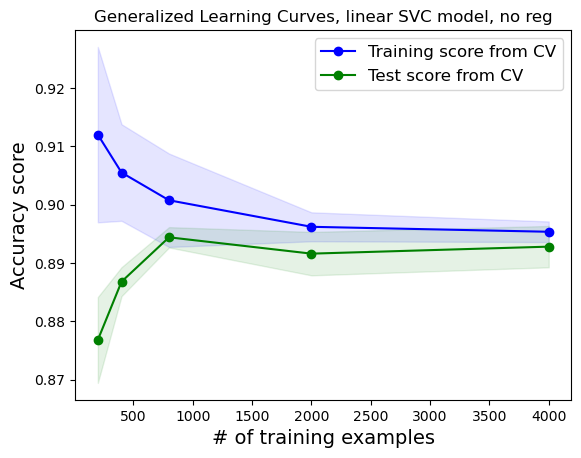

In [39]:
plot_learning_curve(piped_model, 'Generalized Learning Curves, linear SVC model, no reg',
                    features_lim, target, train_sizes = np.array([0.05,0.1,0.2,0.5,1.0]), cv = cv)

Los Learning curves son válidos para un modelo en específico y además parámetros específicos. 
Para 5-fold CV, se tienen tanto 5%, 10%, 20%, 50% y 100% del data, El comportamiento del algoritmo se puede ver a través del gráfico de learning curves tanto para la evolución del training set y el test set performance, como funciones del tamaño del data. 

In [40]:
# Obtener predicciones usando validación cruzada
ypred_linear = cross_val_predict(
    piped_model,
    features_lim,
    target,
    cv=cv
)

#### Genere una matriz de confusión para este modelo y evalúe el desempeño del modelo a partir del resultado.

también puede usar la función [`classification_report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) de `sklearn`

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay 
cm = confusion_matrix(target, ypred_linear)

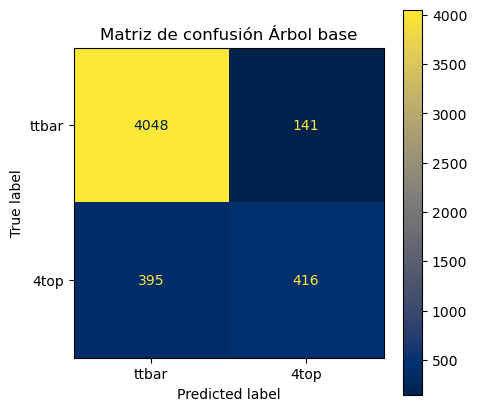

In [42]:
fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["ttbar", "4top"])
disp.plot(cmap="cividis", ax=ax, colorbar=True)
plt.title("Matriz de confusión Árbol base")
plt.show()

In [43]:
from sklearn.metrics import classification_report
print(classification_report(target, ypred_linear))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94      4189
           1       0.75      0.51      0.61       811

    accuracy                           0.89      5000
   macro avg       0.83      0.74      0.77      5000
weighted avg       0.88      0.89      0.88      5000



## Conclusiones del benchmark lineal

1. En la curva de aprendizaje, ¿los scores de entrenamiento y validación son altos o bajos?  
   ¿Están separados o son parecidos?
 Para la curva de aprendizaje para train y test se encuentran inicialmente separados y después tienden a aplanarse. Para los training scores, estos son altos al principio y después disminuyen y se aplanan, debido a que el training set es pequeño entonces permite dar un performance mejor. En cambio, para los test score, tienden a decrecer en función del tamaño del data y también después se aplanan.

3. ¿La curva sugiere alto bias o alta variance?  
   Justifique usando la relación entre score de entrenamiento y validación.  El mismo análisis de las curvas de apredizaje ayudan a evaluar si el incrementar el tamaño del set de data ayudaría a incrementar el performance con algo menos complejo y que en realidad incluya algunos errores, pero estos igual se pueden minimizar.
Para el algoritmo visto y los valores de hiperparámetros, el hecho de agregar más data no ayuda y además el modelo tienen un alto bias, debido a un subajuste del modelo. Esto se puede mejorar optimizando los parámetros del SVM, usando específicamente funciones de kernel más complejos que ayuden al algoritmo.

4. Considerando que usamos \(C=1000\), ¿qué nos dice este resultado sobre la capacidad del modelo lineal? El valor de un C muy grande penaliza las clasificaciones que son incorrectas, distinguiendo fuertemente si es que existe una relación lineal o no entre los datos.
Nota: TP:4048(ttbar-ttbar) , FN:141 (ttbar-4top), FP:395(4top-ttbar), TN:416(4top-4top)
5. En la matriz de confusión, ¿el modelo detecta bien los eventos `4top` o tiende a clasificarlos como `ttbar`? Se detectan mayoritariamente bien los ttbar, pero falta aún una buena clasificación para los 4top, debido al desbalance de clases. 

   
7. ¿qué métrica muestra mejor el problema con la clase minoritaria: accuracy, precision, recall o F1-score? Con la clase minoritaria se muestra mejor la métrica precision. Para la clase minoritaria, la métrica que muestra mejor el problema es justamente el recall, dado que está como al límite de porcentaje con respecto a la completitud. Hay 51% de completitud, pero falta el 49%.

8. ¿El modelo lineal supera realmente los benchmarks ingenuos, o su buen desempeño se explica principalmente por el desbalance de clases? El alto accuracy se explica por el desbalance de clases, principalmente. Debido a que al final el modelo no resulta representativo debido a que se encuentra una clase minoritaria y una muy contundente.

9. ¿Qué evidencia nos indica que necesitamos un modelo más flexible que una frontera lineal? Dado el recall que dió para 4top, donde falta la completitud de 49%, serí para ese evento donde la evidencia es más grande. El evento no está siendo bien clasificado al tener tanto los margenes como limitación principal entre las dos clases (teniendo en cuenta una figura clasificativa como mostrada en diapositivas en clase), de manera que se clasifican mucho los ttbar siendo no generalizable para el modelo completo. Aquello se podría mejorar no "forzando" a que el modelo tenga necesariamente una relación lineal, puede presentarse el caso que tenga una relación no lineal y que se tengan que encontrar límites más complejos que de igual forma contengan un rango de error para explicar las cualidades mismas de la clasificación.

## Optimización de hiperparámetros

[`GridSearchCV`](https://scikit-learn.org/stable/modules/grid_search.html)selecciona los hiperparámetros que obtienen el mejor desempeño promedio en validación cruzada. Sin embargo, ese score puede ser optimista, porque los mismos folds de validación se usaron para elegir la mejor combinación de hiperparámetros.
Para estimar mejor el desempeño esperado en datos nuevos, se puede usar **validación cruzada anidada**. En este procedimiento, una validación cruzada interna selecciona los hiperparámetros, mientras que una validación cruzada externa evalúa el modelo seleccionado.
La idea central es no usar la misma información para elegir el modelo y para reportar su desempeño final.

La validación cruzada anidada es más rigurosa, pero no siempre vale la pena implementarla. Puede ser muy costosa, porque requiere repetir la búsqueda de hiperparámetros dentro de cada fold externo.En este notebook usaremos `GridSearchCV` para seleccionar hiperparámetros y comparar modelos, pero debemos recordar que el mejor score obtenido puede ser algo optimista. Si el objetivo fuera reportar un resultado final de investigación de manera rigurosa, sería mejor usar un conjunto de prueba independiente o validación cruzada anidada.

In [76]:
#ahora usamos la version general SVC y no la lineal, para cambiar el kernel
piped_model = make_pipeline(StandardScaler(), SVC())

piped_model.get_params() # esto nos muestra los parámetros para el scaler y el clasificador

{'memory': None,
 'steps': [('standardscaler', StandardScaler()), ('svc', SVC())],
 'transform_input': None,
 'verbose': False,
 'standardscaler': StandardScaler(),
 'svc': SVC(),
 'standardscaler__copy': True,
 'standardscaler__with_mean': True,
 'standardscaler__with_std': True,
 'svc__C': 1.0,
 'svc__break_ties': False,
 'svc__cache_size': 200,
 'svc__class_weight': None,
 'svc__coef0': 0.0,
 'svc__decision_function_shape': 'ovr',
 'svc__degree': 3,
 'svc__gamma': 'scale',
 'svc__kernel': 'rbf',
 'svc__max_iter': -1,
 'svc__probability': 'deprecated',
 'svc__random_state': None,
 'svc__shrinking': True,
 'svc__tol': 0.001,
 'svc__verbose': False}

### Podemos definir un diccionario de valores parámetros para correr la optimización

Note que esto tomará tiempo (~3 min en mi computador)

Una vez que corramos esta celda, el objeto modelo tendra atributos de "best_score_", "best_params_" y "best_estimator_", que nos da acceso al estimador óptimo y "cv_results_" que pueden ser utilizados para visualizar la performance de todos los modelo

In [47]:
%%time
#optimizando SVC, TODAVIA NO ES CV ANIDADA!

#Probamos kernel polinomial y gaussiano, parámetros gamma y degree,
# además del parámetro de regularización
parameters = {'svc__kernel':['poly', 'rbf'], \
              'svc__gamma':[0.00001,'scale', 0.01, 0.1], 'svc__C':[0.1, 1.0, 10.0, 100.0, 1000], \
              'svc__degree': [2, 4, 8]}

# CV para todos los valores de los parámetros del GridSearch
model = GridSearchCV(piped_model, parameters, cv = StratifiedKFold(n_splits=5, shuffle=True), \
                     verbose = 2, n_jobs = 4, return_train_score=True)
model.fit(features_lim,target)

print('Best params, best score:', "{:.4f}".format(model.best_score_), \
      model.best_params_)

Fitting 5 folds for each of 120 candidates, totalling 600 fits
CPU times: user 34.1 ms, sys: 66.9 ms, total: 101 ms
Wall time: 1.23 s


ValueError: Invalid parameter 'svc' for estimator Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearsvc', LinearSVC(C=1000, dual=False))]). Valid parameters are: ['memory', 'steps', 'transform_input', 'verbose'].

####  Ahora, visualizamos los modelos en un dataframe, y los rankeamos de acuerdo a los scores de prueba.

Miraremos el promedio y desviación estándar de los test scores, el promedio de los train scores, para evaluar si son distintos  y la significancia del resultado, y fitting time, para elegir el modelo más rápido en vez del mejor modelo, si es que los scores son comparables

In [81]:
scores_lim = pd.DataFrame(model.cv_results_)

scores_lim.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_svc__C', 'param_svc__degree', 'param_svc__gamma',
       'param_svc__kernel', 'params', 'split0_test_score', 'split1_test_score',
       'split2_test_score', 'split3_test_score', 'split4_test_score',
       'mean_test_score', 'std_test_score', 'rank_test_score',
       'split0_train_score', 'split1_train_score', 'split2_train_score',
       'split3_train_score', 'split4_train_score', 'mean_train_score',
       'std_train_score'],
      dtype='str')

In [82]:
#el mejor modelo resulta ser svc_C=1, cuando ya no se puede ajustar bien, se tiene que ajustar por las caracteristicas
#{'svc__C': 1.0, 'svc__degree': 2, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}

In [83]:
scores_lim[['params','mean_test_score','std_test_score','mean_train_score', \
            'mean_fit_time']].sort_values(by = 'mean_test_score', ascending = False)

,params,mean_test_score,std_test_score,mean_train_score,mean_fit_time
29,"{'svc__C': 1.0, 'svc__degree': 2, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.8956,0.007310,0.90005,0.066152
45,"{'svc__C': 1.0, 'svc__degree': 8, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.8956,0.007310,0.90005,0.068455
37,"{'svc__C': 1.0, 'svc__degree': 4, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.8956,0.007310,0.90005,0.068044
69,"{'svc__C': 10.0, 'svc__degree': 8, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.8954,0.009790,0.91220,0.080823
53,"{'svc__C': 10.0, 'svc__degree': 2, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.8954,0.009790,0.91220,0.081316
61,"{'svc__C': 10.0, 'svc__degree': 4, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.8954,0.009790,0.91220,0.080909
27,"{'svc__C': 1.0, 'svc__degree': 2, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}",0.8942,0.009368,0.92260,0.079773
35,"{'svc__C': 1.0, 'svc__degree': 4, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}",0.8942,0.009368,0.92260,0.083553
43,"{'svc__C': 1.0, 'svc__degree': 8, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}",0.8942,0.009368,0.92260,0.080898
105,"{'svc__C': 1000, 'svc__degree': 4, 'svc__gamma': 1e-05, 'svc__kernel': 'rbf'}",0.8936,0.005607,0.89365,0.078893


Observamos que el kernel rbf es preferido constantemente, los valores de $C$ y $\gamma$ no afectan demasiado los scores. GridSearch es insensible a combinaciones de parámetros irrelevantes, por ejemplo, los tres primeros modelos son idénticos porque el grado del kernel polinomial no afecta al kernel rbf.

#### Podemos aislar un solo tipo de kernel

In [84]:
#por caracteristica el otro mejor es de 0.8774
#{'svc__C': 10.0, 'svc__degree': 2, 'svc__gamma': 0.1, 'svc__kernel': 'poly'}
scores_lim[scores_lim['param_svc__kernel'] == 'poly'][['params','mean_test_score','std_test_score',\
                        'mean_train_score','mean_fit_time']].sort_values(by = 'mean_test_score', ascending = False)

,params,mean_test_score,std_test_score,mean_train_score,mean_fit_time
54,"{'svc__C': 10.0, 'svc__degree': 2, 'svc__gamma': 0.1, 'svc__kernel': 'poly'}",0.8786,0.003137,0.88700,0.664635
100,"{'svc__C': 1000, 'svc__degree': 2, 'svc__gamma': 0.01, 'svc__kernel': 'poly'}",0.8786,0.003137,0.88695,0.820902
50,"{'svc__C': 10.0, 'svc__degree': 2, 'svc__gamma': 'scale', 'svc__kernel': 'poly'}",0.8780,0.002966,0.88650,0.243205
58,"{'svc__C': 10.0, 'svc__degree': 4, 'svc__gamma': 'scale', 'svc__kernel': 'poly'}",0.8774,0.009047,0.96105,0.174245
38,"{'svc__C': 1.0, 'svc__degree': 4, 'svc__gamma': 0.1, 'svc__kernel': 'poly'}",0.8770,0.009529,0.96215,0.176655
26,"{'svc__C': 1.0, 'svc__degree': 2, 'svc__gamma': 'scale', 'svc__kernel': 'poly'}",0.8766,0.002332,0.88215,0.100994
76,"{'svc__C': 100.0, 'svc__degree': 2, 'svc__gamma': 0.01, 'svc__kernel': 'poly'}",0.8764,0.003007,0.88445,0.147174
30,"{'svc__C': 1.0, 'svc__degree': 2, 'svc__gamma': 0.1, 'svc__kernel': 'poly'}",0.8764,0.003007,0.88445,0.154613
74,"{'svc__C': 100.0, 'svc__degree': 2, 'svc__gamma': 'scale', 'svc__kernel': 'poly'}",0.8764,0.003878,0.88820,1.887753
78,"{'svc__C': 100.0, 'svc__degree': 2, 'svc__gamma': 0.1, 'svc__kernel': 'poly'}",0.8762,0.004534,0.88840,6.064774


In [85]:
best_model = model.best_estimator_

ypred_best = cross_val_predict(
    best_model,
    features_lim,
    target,
    cv=cv
)

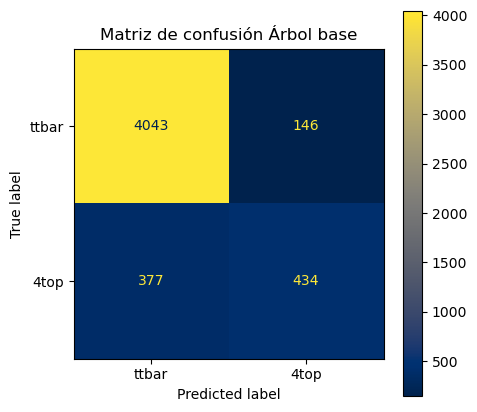

In [90]:
cm = confusion_matrix(target, ypred_best)
fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["ttbar", "4top"])
disp.plot(cmap="cividis", ax=ax, colorbar=True)
plt.title("Matriz de confusión Árbol base")
plt.show()

In [93]:
print(classification_report(target, ypred_best))
#siendo 0 lo mayoritario, 4189
#el 1 es para los raros, osea que son escasos 811

              precision    recall  f1-score   support

           0       0.91      0.97      0.94      4189
           1       0.75      0.54      0.62       811

    accuracy                           0.90      5000
   macro avg       0.83      0.75      0.78      5000
weighted avg       0.89      0.90      0.89      5000



**Construya la matriz de confusión para el modelo optimizado**

Preguntas:

- ¿Cuál es la accuracy del modelo optimizado? Es un 90%
- ¿Cuál es la precision para la clase 4top? Es 75%
- ¿Cuál es el recall para la clase 4top? Es 54%
- ¿Cuál es el F1-score para la clase 4top? Es 62%
- ¿Qué métrica mejoró más respecto al benchmark lineal? mejoró un poco más el recall de 4top principalmente.
- ¿Qué métrica empeoró o cambió muy poco? mejoró un poco el recall y f1-score para 4top, además también mejoró un poco el promedio macro y el promedio weighted para todos. 
- ¿La mejora en accuracy refleja una mejora real para la clase 4top? No en realidad, porque fue demasiado poco la mejora. Pero el accuracy está principalmente "cargada" para los ttbar.
- ¿El modelo optimizado detecta mejor la clase minoritaria que el benchmark lineal? En general diría que sí, a pesar de lo poco que cambió sus valores.

Complete la tabla de comparación


| Modelo            | Accuracy | Precision `4top` | Recall `4top` | F1-score `4top` | Comentario |
| ----------------- | -------: | ---------------: | ------------: | --------------: | ---------- |
| Benchmark lineal  |    0.89      |       0.75           |       0.51        |   0.61              |            |
| Modelo optimizado |    0.90      |       0.75           |      0.54         |   0.62              |            |

- ¿El modelo optimizado mejora todas las métricas o solo algunas? Mejora la mayoría de las métricas. 
- Si una métrica mejora pero otra empeora, ¿cómo decidiría cuál modelo es mejor? Depende de lo que se quiera, porque si se quisiera la completitud para el 4top, debido a que son raros, entonces se escogería el modelo optimizado, por ejemplo. Si se quieren FP, entonces la precisión funcionaría mejor (algo). Además depende de cuán complejo resulte el modelo y cuánto tiempo demore en otorgar las comparaciones. 
- ¿La mejora justifica usar un modelo más complejo? No necesariamente, porque el modelo es complejo podría llevar a perfeccionar demasiado el modelo que estaría sobre-estimando los resultados. En cambio, es preferible que al modelo se le disminuya la complejidad y contenga errores de manera que se pueda estimar representando la muestra.


#### Diagnóstico final

- ¿Qué modelo elegiría para reportar y por qué? Escogería el modelo optimizado, puesto que a pesar de que mejoraron relativamente poco las métricas, "igual mejoraron". 
- ¿Qué limitación importante todavía tiene el modelo? Que aún hay desbalances entre los eventos ttbar y 4top.

## Actividad final: mejorar el modelo

Hasta ahora usamos un conjunto limitado de features para construir y optimizar nuestros modelos. Sin embargo, el desempeño de un modelo no depende solo del algoritmo o de los hiperparámetros: también depende de la información que le entregamos.

En este dataset, cada evento contiene información de varias partículas reconstruidas. Como los eventos `4top` suelen ser más complejos que los eventos `ttbar`, es razonable pensar que usar más información del evento podría ayudar al modelo a distinguir mejor ambas clases.

**Proponga una estrategia para mejorar el modelo explorando nuevas features o usando una representación más completa de los eventos.**

Puede considerar, por ejemplo:

- incluir información de más partículas;
- usar todas las partículas disponibles;
- construir variables derivadas;
- modificar el tratamiento de valores faltantes;
- comparar distintos subconjuntos de features;
- cambiar la métrica usada para optimizar el modelo.

Luego evalúe si su propuesta mejora el desempeño respecto al modelo anterior.


<h2 style="color:Fuchsia; font-family:; text-align:center;font-size:25px">
  ❁۪ ｡˚ Nueva estrategia ❁۪ ｡˚
</h2>

Una nueva estrategia puede ser inlcuir todos los features, es decir, no limitar a 16 columnas (4 productos). Además el considerar rellenar tanto manual o automáticamente con 0 en los datos faltantes como NaN, para así "trazar" entre todas las features e igual teniendo los targets para tratar de mejorar el accuracy que ha sido repercutido por el desbalance de clases, lo que afecta principalmente el recall que es lo que se quiere para mejorar el modelo respecto a 4top.

In [44]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [45]:
features_new = pd.read_csv('ParticleID_features.csv', index_col='ID')

In [46]:
features_new.shape
y_new = np.genfromtxt('ParticleID_labels.txt', dtype = str)
from sklearn.preprocessing import LabelEncoder
le_new = LabelEncoder() 
y_new = le_new.fit_transform(y_new)
le_new.classes_
target_new = np.abs(y_new - 1)

In [47]:
features_new.shape

(5000, 67)

In [81]:
#como antes se ven las clases, que valores tienen, si hay NaN
print(features_new[:5])
print(le_new.classes_)
print(np.unique(target_new, return_counts=True))

        MET    METphi Type_1        P1        P2        P3        P4 Type_2  \
ID                                                                            
0   62803.5 -1.810010      j  137571.0  128444.0 -0.345744 -0.307112      j   
1   57594.2 -0.509253      j  161529.0   80458.3 -1.318010  1.402050      j   
2   82313.3  1.686840      b  167130.0  113078.0  0.937258 -2.068680      j   
3   30610.8  2.617120      j  112267.0   61383.9 -1.211050 -1.457800      b   
4   45153.1 -2.241350      j  178174.0  100164.0  1.166880 -0.018721      j   

          P5        P6        P7        P8 Type_3        P9      P10  \
ID                                                                     
0   174209.0  127932.0  0.826569  2.332000      b   86788.9  84554.9   
1   291490.0   68462.9 -2.126740 -2.582310     e-   44270.1  35139.6   
2   102423.0   54922.3  1.226850  0.646589      j   60768.9  36244.3   
3    40647.8   39472.0 -0.024646 -2.222800      j  201589.0  32978.6   
4    92351.3  

In [82]:
#aquí se ven cuales son categóricas y numéricas
cat_cols = features_new.select_dtypes(include=['object']).columns
num_cols = features_new.select_dtypes(exclude=['object']).columns
print(list(cat_cols)) #categóricas
print(list(num_cols)) #numéricas

['Type_1', 'Type_2', 'Type_3', 'Type_4', 'Type_5', 'Type_6', 'Type_7', 'Type_8', 'Type_9', 'Type_10', 'Type_11', 'Type_12', 'Type_13']
['MET', 'METphi', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15', 'P16', 'P17', 'P18', 'P19', 'P20', 'P21', 'P22', 'P23', 'P24', 'P25', 'P26', 'P27', 'P28', 'P29', 'P30', 'P31', 'P32', 'P33', 'P34', 'P35', 'P36', 'P37', 'P38', 'P39', 'P40', 'P41', 'P42', 'P43', 'P44', 'P45', 'P46', 'P47', 'P48', 'P49', 'P50', 'P51', 'P52']


/var/folders/36/rk32flss4bj4sbk5qc_2v8l00000gn/T/ipykernel_49332/2076981060.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = features_new.select_dtypes(include=['object']).columns


In [155]:
#dado que se tienen string que no se pueden tratar como variables numéricas
#se usa one-hot encoding para tratar los j, etc (aquí busqué por internet)
#El one-hot encoding técnica de preprocesamiento de datos que 
#transforma variables categóricas en columnas binarias (con valores 0 y 1) 
#para que los modelos de aprendizaje automático puedan procesarlas
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)
X_cat = encoder.fit_transform(features_new[cat_cols])
#xcat tiene las variables categoricas convertidas a numéricas

In [157]:
X_cat.shape #esto es lo nuevo, que convirtió variables categóricas a numéricas

(5000, 97)

In [158]:
#aquí busqué en la ia como relacionar esta parte, dado que 
#como se convirtieron las variables categóricas
#se otorgan a cada tipo su variable categórica por separado
encoder.get_feature_names_out()

array(['Type_1_b', 'Type_1_j', 'Type_2_b', 'Type_2_e+', 'Type_2_e-',
       'Type_2_g', 'Type_2_j', 'Type_2_m+', 'Type_2_m-', 'Type_2_nan',
       'Type_3_b', 'Type_3_e+', 'Type_3_e-', 'Type_3_g', 'Type_3_j',
       'Type_3_m+', 'Type_3_m-', 'Type_3_nan', 'Type_4_b', 'Type_4_e+',
       'Type_4_e-', 'Type_4_g', 'Type_4_j', 'Type_4_m+', 'Type_4_m-',
       'Type_4_nan', 'Type_5_b', 'Type_5_e+', 'Type_5_e-', 'Type_5_g',
       'Type_5_j', 'Type_5_m+', 'Type_5_m-', 'Type_5_nan', 'Type_6_b',
       'Type_6_e+', 'Type_6_e-', 'Type_6_g', 'Type_6_j', 'Type_6_m+',
       'Type_6_m-', 'Type_6_nan', 'Type_7_b', 'Type_7_e+', 'Type_7_e-',
       'Type_7_g', 'Type_7_j', 'Type_7_m+', 'Type_7_m-', 'Type_7_nan',
       'Type_8_b', 'Type_8_e+', 'Type_8_e-', 'Type_8_g', 'Type_8_j',
       'Type_8_m+', 'Type_8_m-', 'Type_8_nan', 'Type_9_b', 'Type_9_e+',
       'Type_9_e-', 'Type_9_g', 'Type_9_j', 'Type_9_m+', 'Type_9_m-',
       'Type_9_nan', 'Type_10_b', 'Type_10_e+', 'Type_10_e-', 'Type_10_g',
       '

In [159]:
X_num = features_new[num_cols]
X_num = X_num.to_numpy()
X_num.shape

(5000, 54)

In [160]:
#combinacion de categóricas y numéricas
X_all = np.hstack([
    X_num,
    X_cat
])

In [161]:
X_all.shape

(5000, 151)

In [162]:
print(features_new.isna().sum().sum()) #se ven el total de valores faltantes

168865


In [163]:
missing = features_new.isna().sum()
print(missing.sort_values(ascending=False))
#aquí se ven cuantos valores faltantes hay por categoría

P52        4944
P51        4944
P50        4944
P49        4944
Type_13    4944
P46        4873
Type_12    4873
P45        4873
P47        4873
P48        4873
P44        4739
P43        4739
P42        4739
P41        4739
Type_11    4739
P38        4558
Type_10    4558
P37        4558
P40        4558
P39        4558
P36        4271
P35        4271
P34        4271
P33        4271
Type_9     4271
P32        3814
P31        3814
P30        3814
P29        3814
Type_8     3814
P26        3111
P28        3111
P27        3111
P25        3111
Type_7     3111
P24        2129
P23        2129
P22        2129
P21        2129
Type_6     2129
P20         998
P19         998
P18         998
P17         998
Type_5      998
Type_4      283
P13         283
P14         283
P15         283
P16         283
P12          50
P11          50
P10          50
P9           50
Type_3       50
P8            3
P7            3
P6            3
P5            3
Type_2        3
P2            0
Type_1        0
P1      

In [164]:
features_new.dropna()

,MET,METphi,Type_1,P1,P2,P3,P4,Type_2,P5,P6,P7,P8,Type_3,P9,P10,P11,P12,Type_4,P13,P14,P15,P16,Type_5,P17,P18,P19,P20,Type_6,P21,P22,P23,P24,Type_7,P25,P26,P27,P28,Type_8,P29,P30,P31,P32,Type_9,P33,P34,P35,P36,Type_10,P37,P38,P39,P40,Type_11,P41,P42,P43,P44,Type_12,P45,P46,P47,P48,Type_13,P49,P50,P51,P52
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
27,32576.00,1.059770,j,1067060.0,182627.0,2.449920,2.847500,b,185583.0,175843.0,-0.020077,-1.393810,j,136264.0,130954.0,-0.165183,0.855485,j,108929.0,99168.9,-0.421980,-0.411110,b,139073.0,78795.9,1.161890,-1.107700,j,276656.0,76763.5,-1.954990,-0.105731,j,188169.0,71434.3,1.622490,3.061770,j,1628820.0,43038.3,-4.326470,0.188013,j,152431.0,42846.6,-1.940220,2.406420,j,35605.0,33213.7,-0.360886,1.557250,j,983864.0,32094.4,4.115640,-0.348669,j,253575.0,23909.1,3.052020,-2.259730,e+,229263.0,120849.0,-1.255400,2.611680
30,105791.00,2.836420,b,207770.0,114087.0,-1.200750,-1.263980,j,154147.0,99296.0,-1.004230,0.151114,j,80471.9,79461.4,0.131087,2.400010,b,86732.0,67346.2,0.734247,2.750700,b,65413.5,64342.1,0.039533,0.791519,b,342518.0,63795.6,-2.364510,-0.451688,j,185041.0,63651.7,1.728000,-0.808180,j,60788.7,47862.8,0.711567,1.969790,j,102142.0,47644.9,1.394890,2.317680,j,54864.4,40220.6,0.809124,-1.661430,j,392048.0,31033.6,-3.227770,1.555740,j,65841.2,28472.2,-1.478970,-0.610641,e-,123613.0,34018.5,-1.963900,-1.772980
100,45412.50,1.470110,b,220384.0,195726.0,0.478496,-2.036890,b,253403.0,156312.0,-1.058850,1.514780,j,341513.0,148204.0,1.475390,-1.595720,j,111465.0,84824.1,-0.752946,0.681576,j,1548790.0,58053.3,3.976620,2.971370,j,201345.0,55206.5,-1.966850,0.259292,j,72057.1,49368.2,0.903603,-0.119793,j,47592.1,44278.5,-0.380611,-2.162610,j,46317.3,43994.6,-0.292453,1.608220,j,37213.4,37059.3,0.062275,-2.687360,j,59724.5,36846.0,1.054910,0.800767,b,46700.9,33955.7,0.824728,1.982500,j,105857.0,27225.1,2.032270,2.830860
138,27423.30,-2.863890,j,278378.0,103721.0,1.642880,-0.125401,j,220297.0,86454.4,1.586040,0.492328,j,309643.0,65589.8,2.231510,1.737800,j,526845.0,63152.9,-2.810700,-1.866080,j,169955.0,54810.5,-1.790260,1.850320,b,82552.1,53766.9,0.990833,-1.808060,b,62381.3,48749.2,-0.712356,2.458980,j,49734.3,46223.5,0.347442,-2.237500,j,56827.5,42507.9,0.786115,-0.554034,j,107489.0,40459.8,1.629280,2.146080,j,63901.8,36905.2,-1.145590,-1.490630,j,243544.0,35624.8,-2.608850,3.045970,j,141613.0,30507.3,2.214780,-1.044960
369,57596.50,2.632250,j,324736.0,314634.0,-0.067070,-2.890870,b,284749.0,230824.0,-0.665745,0.811894,b,203460.0,157336.0,-0.745391,0.196807,j,785423.0,131547.0,-2.472150,-1.266690,j,201547.0,105150.0,1.243530,-0.055627,j,742192.0,96187.9,2.732010,-2.252830,j,200687.0,70888.5,-1.697220,-0.440428,b,108823.0,54153.4,1.315170,-2.912630,j,226469.0,49195.2,-2.206800,1.929110,j,538083.0,36994.1,3.369050,-2.938150,j,155930.0,35861.4,2.146010,-0.445190,j,53051.2,30935.7,1.133100,1.353490,j,198466.0,24251.0,2.790980,2.543690
530,138327.00,-2.396390,j,356520.0,330268.0,0.363408,1.468300,j,286782.0,208696.0,-0.828399,-0.579743,b,203478.0,132776.0,0.983844,-2.655640,j,180310.0,60717.3,-1.748010,-0.221699,j,541032.0,58436.7,2.915620,2.536270,j,126761.0,57818.1,1.411690,1.574300,b,55759.6,55492.6,0.020914,-2.931170,b,117144.0,39549.9,-1.746870,-1.398000,j,634355.0,30978.0,3.711810,0.719897,j,60562.9,28651.0,-1.374990,-2.504640,j,28854.7,25264.2,0.499117,-0.132066,e-,54315.2,54235.3,0.054272,-1.518670,g,38396.6,28893.0,0.790348,-1.251560
755,216526.00,-1.582720,b,408369.0,249871.0,1.063650,-0.751857,b,485850.0,226003.0,1.398590,-1.912780,j,185893.0,178310.0,-0.092618,1.862390,j,488364.0,174867.0,-1.684300,1.852730,j,469068.0,148769.0,1.811620,-0.617198,j,174372.0,118620.0,-0.907506,2.268510,j,423667.0,91996.2,2.207950,2.313500,j,233158.0,72373.1,1.836590,1.425930,j,78067.5,72273.7,-0.355328,1.092570,j,93616.3,49483.0,-1.248690,1.181950,j,32360.2,32336.6,-0.014372,2.457800,j,143610.0,30142.5,-2.242570,-2.523610,j,48797.9,25914.6,-1.239350,2.862900
789,67672.5

In [165]:
#convertir los Nan a categoria explicita
features_new_cat = features_new[cat_cols].fillna("missing")

In [166]:
encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)
X_cat = encoder.fit_transform(features_new_cat)

In [167]:
#imputar variables numericas
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X_num = imputer.fit_transform(features_new[num_cols])

In [168]:
print(np.isnan(X_num).sum())
#aquí se verifica que ninguna categoría quede con valores faltantes

0


In [169]:
features_new_cat = features_new[cat_cols].fillna("missing")

encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

X_cat = encoder.fit_transform(features_new_cat)
imputer = SimpleImputer(strategy='median')
X_num = imputer.fit_transform(features_new[num_cols])
X_all = np.hstack([X_num, X_cat])

In [170]:
print(X_all.shape)

(5000, 151)


In [171]:
#lo que se tenía antes
y_new = np.genfromtxt('ParticleID_labels.txt', dtype=str)
from sklearn.preprocessing import LabelEncoder
le_new = LabelEncoder() 
y_new = le_new.fit_transform(y_new)
target_new = np.abs(y_new - 1)

In [172]:
le_new.classes_

array(['4top', 'ttbar'], dtype='<U5')

In [173]:
np.unique(target_new, return_counts=True)
#de la clase 0 se tienen 4189 y de la clase 1 hay 811

(array([0, 1]), array([4189,  811]))

In [174]:
from sklearn.model_selection import train_test_split
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_all,
    target_new,
    test_size=0.25,
    random_state=42,
    stratify=target_new
)

In [175]:
print(X_train_new.shape)
print(X_test_new.shape)

(3750, 151)
(1250, 151)


In [176]:
#Se ven cuantas categóricas y numéricas se tienen
print("Categóricas:", len(cat_cols))
print("Numéricas:", len(num_cols))
print("X_cat:", X_cat.shape)
print("X_num:", X_num.shape)
print("X_all:", X_all.shape)

Categóricas: 13
Numéricas: 54
X_cat: (5000, 97)
X_num: (5000, 54)
X_all: (5000, 151)


In [188]:
from sklearn.ensemble import RandomForestClassifier
model_new = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
model_new.fit(X_train_new, y_train_new)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [178]:
y_pred_new = model_new.predict(X_test_new)

In [179]:
from sklearn.metrics import accuracy_score
accuracy_new = accuracy_score(y_test_new, y_pred_new)
print("Accuracy:", accuracy_new)

Accuracy: 0.936


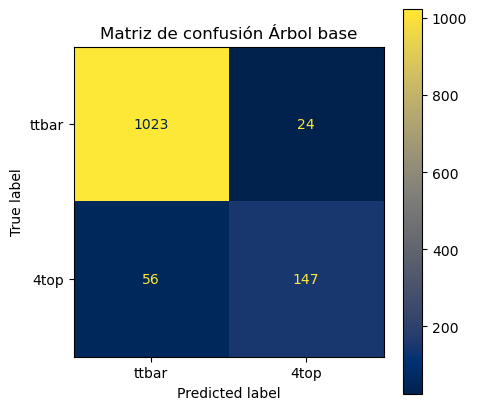

In [180]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test_new, y_pred_new)
fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["ttbar", "4top"])
disp.plot(cmap="cividis", ax=ax, colorbar=True)
plt.title("Matriz de confusión Árbol base")
plt.show()

In [181]:
from sklearn.metrics import classification_report
print(classification_report(y_test_new, y_pred_new))

              precision    recall  f1-score   support

           0       0.95      0.98      0.96      1047
           1       0.86      0.72      0.79       203

    accuracy                           0.94      1250
   macro avg       0.90      0.85      0.87      1250
weighted avg       0.93      0.94      0.93      1250



In [182]:
#ahora usamos la version general SVC y no la lineal, para cambiar el kernel
piped_model = make_pipeline(StandardScaler(), SVC())c
piped_model.get_params() # esto nos muestra los parámetros para el scaler y el clasificador

{'memory': None,
 'steps': [('standardscaler', StandardScaler()), ('svc', SVC())],
 'transform_input': None,
 'verbose': False,
 'standardscaler': StandardScaler(),
 'svc': SVC(),
 'standardscaler__copy': True,
 'standardscaler__with_mean': True,
 'standardscaler__with_std': True,
 'svc__C': 1.0,
 'svc__break_ties': False,
 'svc__cache_size': 200,
 'svc__class_weight': None,
 'svc__coef0': 0.0,
 'svc__decision_function_shape': 'ovr',
 'svc__degree': 3,
 'svc__gamma': 'scale',
 'svc__kernel': 'rbf',
 'svc__max_iter': -1,
 'svc__probability': 'deprecated',
 'svc__random_state': None,
 'svc__shrinking': True,
 'svc__tol': 0.001,
 'svc__verbose': False}

### Preguntas

1. ¿Qué cambio hizo? Lo que se hizo primero fue verificar nuevamente la tabla, que contiene valores faltantes, variables categóricas y numéricas. Entonces primero se separaron esas variables para considerar el uso de one hot encoding, que trabaja con los datos que son categóricos para transformarlos a binarios y para cada uno se agregan nuevas categorías de acuerdo a los tipo de partícula, (electrón, positrón, fotón, jet, b-jet, muón con carga positiva, muón con carga negativa). Y esas columnas se agregaron a la tabla, además para las variables numéricas se reemplazan los Nan con sus medianas, y se verifica que no queden variables con NaN. Con ello la cantidad de variables son en total 151. En este caso se trabajan 1000 datos de prueba
4. ¿Mejoró la detección de eventos `4top`? Si mejoró la detección. Primero ha mejorado el accuracy a 0.935 respecto a lo de antes. Y para la matriz de confusión se tiene 94% de accuracy. Esto es el máximo de mejora que se obtuvo considerando entre 20% y 30% de los datos.
5. ¿Qué ocurrió con la matriz de confusión? Podría decirse que se "estabilizó" un poco más respecto a la matriz de confusión de antes, tanto antes de ser optimizada como cuando fue optimizada al considerar solo 16 columnas. Por lo menos aumentó el recall, que era lo que se quería aumentar para una completitud de los datos 4top con un 72%, pero de todas formas hay que tener cuidado con tomar todos los features porque complica el análisis. En general para la variable 4top, aumentaron las métricas. También un poco para ttbar, pero no tan considerablemente como para 4top.
6. ¿La mejora justifica el aumento de complejidad? No necesariamente, porque esta vez aunque se aumentaron las features, se disminuyó la cantidad de datos de prueba, lo que entre rangos 20% y 30% de la muestra permite obtener un accuracy de 94% como test accuracy score. Además ocurre que hay mucha varianza, lo que provoca un costo computacional más alto.
7. ¿Qué aprendió sobre la importancia de las features en este problema? En general, para el modelo lineal las variables resultan óptimas en primeras instancias pero claramente pueden mejorarse. Al agregar features adicionales estos pueden resultar como ruidosos y no relevantes. Aquello provoca que todos los modelos sufran de alta varianza, por ejemplo para modelo lineal o casi lineales. Esto resulta mayor para el caso de kernel polynomial o Gaussiano con altos C o valores gamma altos. El hecho de involucrar más features hace aumentar la varianza y también el costo computacional sin en realidad mejorar mucho los test scores, a pesar de accuracy mejor, no podría estar generalizando mejor el modelo, dado que si se están buscando más y más variables; complica más el análisis y además puede sobreajustar.

Luego, el mejor modelo de los tratados sería el modelo lineal de 16 columnas, debido a que igual tiene valores altos de accuracy incluidos incertezas que es más razonable que tener un modelo muy perfecto que sobreestime el data. Además de considerar de tener la menor cantidad varianza, entonces se preferiría un alto bias. Respecto a los métodos de kernel aquello funcionan para el espacio de features lo que implica que se haga una evaluación de las funciones de kernel para tratar los datos, además el mismo SVM limita la cantidad de vectores de soporte los que ayudarán establecer la clasificación, lo que no toma todos los datos. Por último, al ser el SVM paramétrico requiere de escalamiento considerando que no todos los modelos tienen relación lineal.